<a href="https://colab.research.google.com/github/Zarrialvi/Airport-Recognition-system/blob/main/Air1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

════════════════════════════════════════════════════════════
  Checking dependencies …
  ✅ All packages already installed.
════════════════════════════════════════════════════════════

╔══════════════════════════════════════════════════════════════╗
║     AIRPORT FACIAL RECOGNITION SYSTEM  v3.0                 ║
║     AeroSafe  –  Full-Featured Security Platform             ║
╚══════════════════════════════════════════════════════════════╝
🔧 Generating demo data (synthetic encodings – no real images needed)…
 Flight BA242  LHR → JFK  Gate A12
 Flight EK501  DXB → LHR  Gate B07
 Flight QR007  DOH → LAX  Gate C03
 Flight SQ318  SIN → SYD  Gate D15
 Registered: Ali Khan  ID:15B4B5EC  Status:CLEARED  [demo-encoding]
 Registered: Babar Azam  ID:71208C32  Status:CLEARED  [demo-encoding]
 Registered: Kamran Khan  ID:A4A9AC8C  Status:VIP  [demo-encoding]
 Registered: Umer Ali  ID:441C95EC  Status:CREW  [demo-encoding]
 Registered: Umar farooq  ID:2C650423  Status:WATCHLIST  [demo-encoding]
 Re

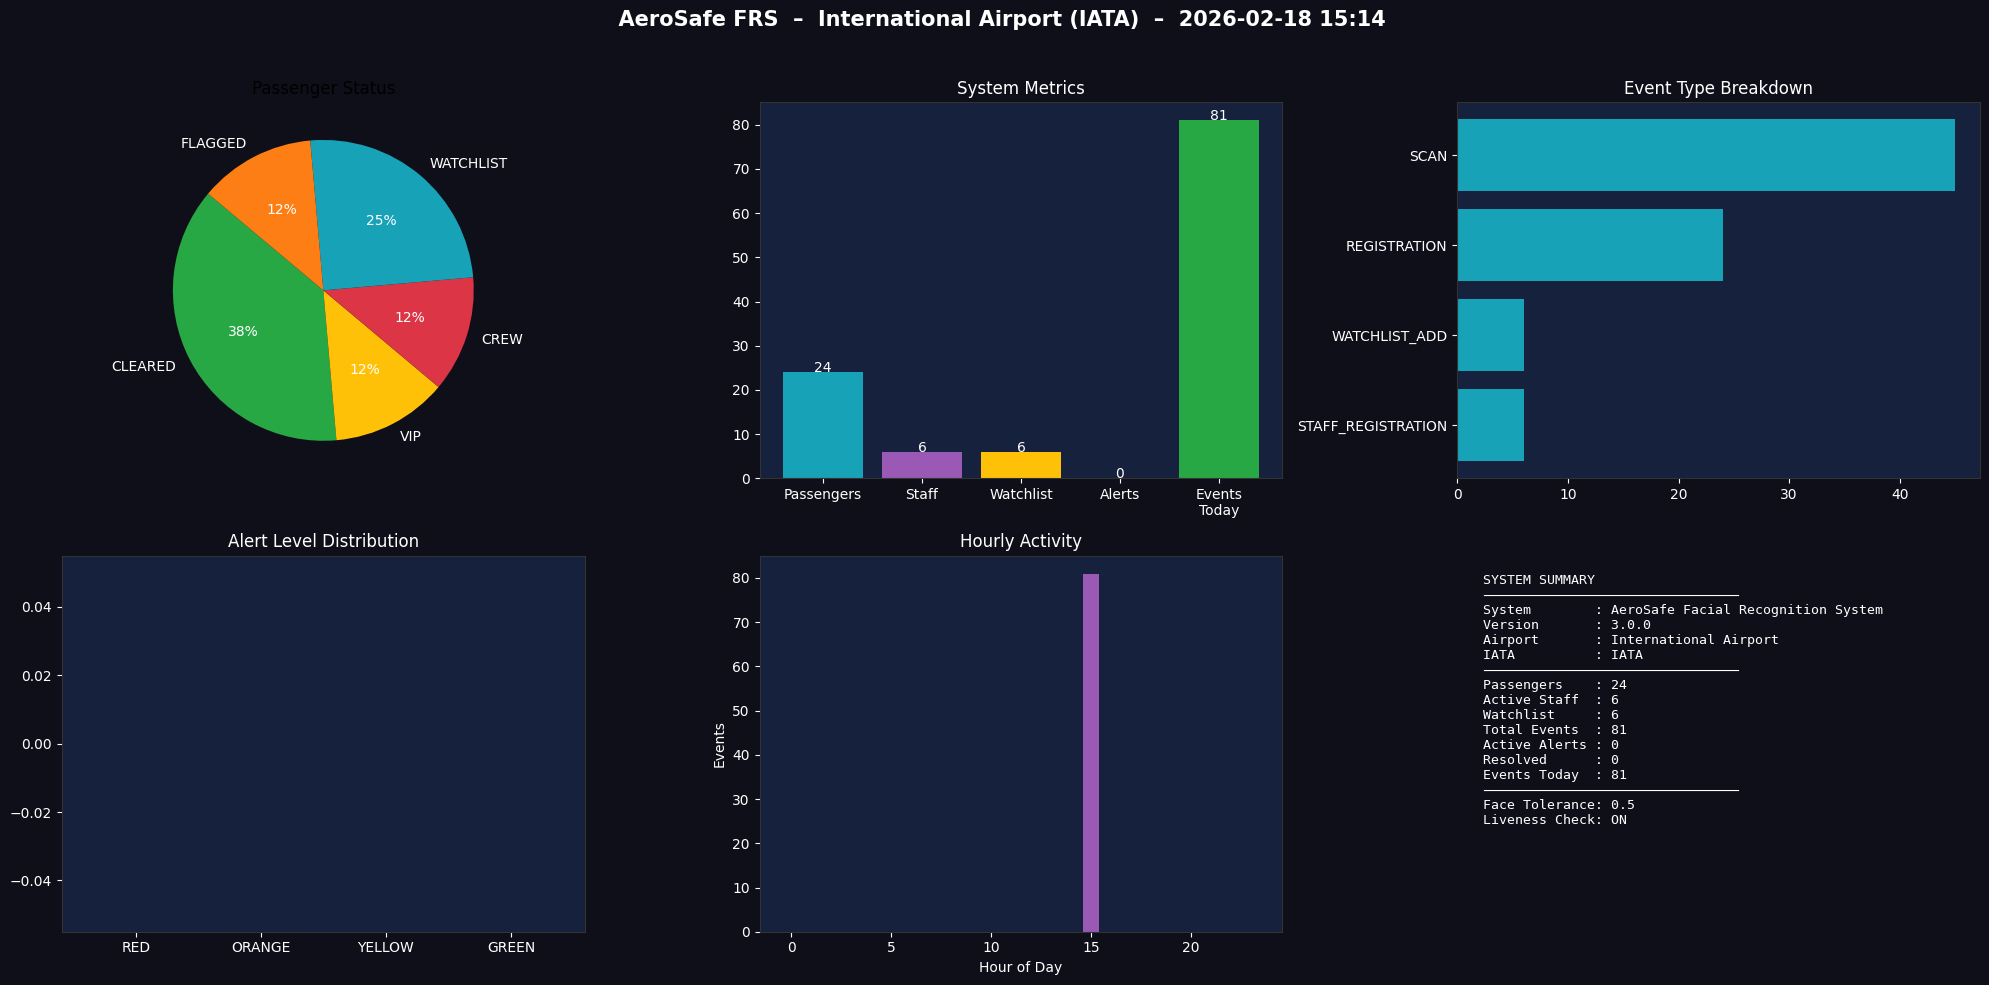

─── Demo: Identity Lookup (synthetic encodings) ─────────
  Querying encoding for demo passenger 0...
  Matched  : Alice Johnson  (ID: 6FF9D820)
  Confidence : 100.0%
  Status     : CLEARED
 No active alerts.


─── Auth Demo ──────────────────────────────────────────
Logged in as 'admin' (role: admin)
  Session: admin (admin)    Expires in: 3599s
'admin' logged out.

─── Available Panels ───────────────────────────────────
  ui.registration_form()               # Register a new passenger
  ui.scan_panel()                      # Upload & scan an image
  ui.search_panel()                    # Search passengers + travel history
  ui.staff_panel()                     # Manage staff
  ui.watchlist_panel()                 # Manage watchlist
  ui.alert_panel()                     # View & resolve alerts
  ui.config_panel()                    # Tune system settings

─── Useful Methods ─────────────────────────────────────
  frs.show_dashboard()              # Analytics dashboard
  frs.health_c

In [ ]:
"""
╔══════════════════════════════════════════════════════════════════════════╗
║    AIRPORT FACIAL RECOGNITION SYSTEM  v3.1                              ║
║    Works on  Google Colab  |  Windows  |  Linux  |  macOS               ║
╠══════════════════════════════════════════════════════════════════════════╣
║  FEATURES                                                                ║
║  ──────────────────────────────────────────────────────────────────────  ║
║  Auto-installs all required packages on first run                     ║
║  Works locally (Windows/Linux/macOS) AND in Google Colab              ║
║  Face Detection, Encoding & Multi-face Identification                 ║
║  Staff / Crew Management                                              ║
║  Liveness Detection (anti-spoofing)                                   ║
║  Session & Auth System (role-based access)                            ║
║  Passenger Search (name / passport / nationality / flight)            ║
║  Watchlist Add & Remove                                               ║
║  Per-Passenger Travel / Checkpoint History                            ║
║  CSV & Excel Export                                                   ║
║  Runtime Config Update                                                ║
║  Image Quality Gate (blur / brightness / size)                        ║
║  Single-Face Registration Guard                                       ║
║  Face Encoding Cleanup on Deletion                                    ║
║  System Health Check                                                  ║
║  Full Analytics Dashboard (matplotlib)                                ║
╚══════════════════════════════════════════════════════════════════════════╝

HOW TO RUN
──────────
  Local (Windows / Linux / macOS):
      python airport_facial_recognition_v3.py
      → packages install automatically on first run

  Google Colab:
      Paste into a cell and run. Packages auto-install.
"""

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 0 – AUTO PACKAGE INSTALLER
# ═══════════════════════════════════════════════════════════════════════════

import sys
import subprocess
import importlib

# Map: import_name → pip install name
REQUIRED_PACKAGES = {
    "cv2":           "opencv-python",
    "numpy":         "numpy",
    "pandas":        "pandas",
    "matplotlib":    "matplotlib",
    "PIL":           "Pillow",
    "ipywidgets":    "ipywidgets",
    "openpyxl":      "openpyxl",
    "face_recognition": "face_recognition",
    "deepface":      "deepface",
    "tf_keras":      "tf-keras",
}

def _install(pkg: str):
    print(f"  📦 Installing {pkg} …")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", pkg],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.STDOUT,
    )

print("═" * 60)
print("  Checking dependencies …")
missing = []
for import_name, pip_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing.append((import_name, pip_name))

if missing:
    print(f"  Installing {len(missing)} missing package(s):")
    for imp, pip in missing:
        _install(pip)
    print("  ✅ All packages installed. Continuing …")
else:
    print("  ✅ All packages already installed.")
print("═" * 60)


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 – IMPORTS & CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

import os
import cv2
import csv
import json
import uuid
import time
import math
import pickle
import shutil
import hashlib
import logging
import datetime
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets

from PIL      import Image, ImageDraw, ImageFont
from io       import BytesIO, StringIO
from pathlib  import Path
from typing   import Optional, List, Dict, Tuple, Any

# ── Environment detection ─────────────────────────────────────────────────
def _detect_env() -> str:
    """Returns 'colab', 'jupyter', or 'terminal'."""
    try:
        from google.colab import files  # noqa
        return "colab"
    except ImportError:
        pass
    try:
        shell = get_ipython().__class__.__name__  # type: ignore
        if shell == "ZMQInteractiveShell":
            return "jupyter"
    except NameError:
        pass
    return "terminal"

ENV = _detect_env()
IN_COLAB   = (ENV == "colab")
IN_JUPYTER = (ENV in ("colab", "jupyter"))

# Set matplotlib backend BEFORE any figure is created
if not IN_JUPYTER:
    matplotlib.use("Agg")   # headless – no GUI popup; charts saved as PNG files

# ── Colab-specific helpers ────────────────────────────────────────────────
if IN_COLAB:
    from google.colab         import files as colab_files   # type: ignore
    from google.colab.patches import cv2_imshow             # type: ignore
else:
    colab_files = None  # type: ignore

    def cv2_imshow(img: np.ndarray):
        """Show an image in Jupyter inline or save PNG for terminal."""
        if IN_JUPYTER:
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
            plt.figure(figsize=(10, 6))
            plt.imshow(rgb)
            plt.axis("off")
            plt.tight_layout()
            plt.show()
        else:
            out = "last_scan_frame.png"
            cv2.imwrite(out, img)
            print(f"  Frame saved -> {out}")

# ── IPython display helpers ───────────────────────────────────────────────
if IN_JUPYTER:
    from IPython.display import display as ipy_display, HTML, clear_output
else:
    def ipy_display(obj):          # Plain terminal fallback
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)
    def clear_output(wait=False):  # noqa
        os.system("cls" if os.name == "nt" else "clear")
    class HTML:                    # noqa
        def __init__(self, s): self.s = s
        def __repr__(self): return self.s

def display(obj):
    """Wrapper that works in all environments."""
    ipy_display(obj)

# ── File upload helper ────────────────────────────────────────────────────
def upload_files() -> Dict[str, bytes]:
    """
    In Colab  → uses google.colab.files.upload()
    Elsewhere → prompts for a file path and reads it
    """
    if IN_COLAB:
        return colab_files.upload()

    # Local fallback: ask for a path
    path_str = input("  Enter path to image file: ").strip().strip('"').strip("'")
    p = Path(path_str)
    if not p.exists():
        print(f"  File not found: {p}"); return {}
    return {p.name: p.read_bytes()}

def download_file(filepath: str):
    """Download / open a file for the user."""
    if IN_COLAB:
        colab_files.download(filepath)
    else:
        print(f"  📁 File saved at: {Path(filepath).resolve()}")


def plt_show(save_path: str = None):
    """
    Show or save a matplotlib figure depending on the environment.
    - Jupyter / Colab : plt.show() renders inline
    - Terminal        : saves PNG and prints the path (Agg backend has no display)
    """
    if IN_JUPYTER:
        plt.show()
    else:
        out = save_path or "frs_plot.png"
        plt.savefig(out, dpi=120, bbox_inches="tight")
        plt.close()
        print(f"  Chart saved to: {Path(out).resolve()}")
# ──────────────── LOGGING ────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("AirportFRS")

# ──────────────── SYSTEM CONFIGURATION ──────────────────────────────────
CONFIG: Dict[str, Any] = {
    # Identity
    "system_name":           "AeroSafe Facial Recognition System",
    "version":               "3.0.0",
    "airport_name":          "International Airport",
    "iata_code":             "IATA",

    # Recognition tuning
    "face_tolerance":        0.50,        # Lower = stricter (0.0–1.0)
    "min_face_size":         (60, 60),    # Minimum pixel dimensions
    "confidence_threshold":  0.60,        # Below this → UNRECOGNIZED

    # Security features
    "liveness_check":        True,        # Reject static/printed photos
    "blur_threshold":        80.0,        # Laplacian variance; below = too blurry
    "brightness_min":        40,          # 0-255; below = too dark
    "brightness_max":        230,         # 0-255; above = overexposed
    "max_login_attempts":    3,
    "session_timeout":       3600,        # Seconds (1 hour)

    # Alert tuning
    "alert_cooldown":        30,          # Seconds between duplicate alerts

    # Storage paths
    "db_path":               "airport_frs_db",
    "logs_path":             "airport_frs_logs",
    "backup_path":           "airport_frs_backup",
    "exports_path":          "airport_frs_exports",

    # Analysis features (disable to speed up)
    "emotion_detection":     True,
    "age_gender_detection":  True,
}

# ──────────────── CONSTANTS ───────────────────────────────────────────────
ALERT_LEVELS: Dict[str, Dict] = {
    "GREEN":  {"color": "#28a745", "priority": 0, "description": "Normal – No threats"},
    "YELLOW": {"color": "#ffc107", "priority": 1, "description": "Caution – Monitoring required"},
    "ORANGE": {"color": "#fd7e14", "priority": 2, "description": "Elevated – Possible match"},
    "RED":    {"color": "#dc3545", "priority": 3, "description": "Critical – Immediate action"},
}

PASSENGER_STATUS: Dict[str, str] = {
    "CLEARED":      "Cleared",
    "WATCHLIST":    "Watchlist",
    "NO_FLY":       "No-Fly List",
    "VIP":          "VIP",
    "CREW":         "Crew",
    "UNRECOGNIZED": "Unrecognized",
    "FLAGGED":      "Flagged",
}

STAFF_ROLES: List[str] = [
    "Security Officer", "Immigration Officer", "Customs Officer",
    "System Administrator", "Supervisor", "Ground Staff",
]

CHECKPOINTS: List[str] = [
    "Check-in", "Security Gate", "Boarding Gate",
    "Immigration", "Customs", "VIP Lounge",
]

USER_ROLES: List[str] = ["admin", "operator", "viewer"]

# Default operator accounts (passwords are SHA-256 hashed)
# Default credentials:  admin/admin123  |  operator/op123  |  viewer/view123
_DEFAULT_ACCOUNTS: Dict[str, Dict] = {
    "admin":    {"password_hash": hashlib.sha256(b"admin123").hexdigest(),   "role": "admin"},
    "operator": {"password_hash": hashlib.sha256(b"op123").hexdigest(),      "role": "operator"},
    "viewer":   {"password_hash": hashlib.sha256(b"view123").hexdigest(),    "role": "viewer"},
}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 – IMAGE QUALITY CHECKER  (NEW in v3)
# ═══════════════════════════════════════════════════════════════════════════

class ImageQualityChecker:
    """
    Gates images before face encoding to reject blurry, over/under-exposed,
    or obviously spoofed (static printout) submissions.
    """

    @staticmethod
    def laplacian_variance(gray: np.ndarray) -> float:
        """Higher = sharper."""
        return float(cv2.Laplacian(gray, cv2.CV_64F).var())

    @staticmethod
    def mean_brightness(gray: np.ndarray) -> float:
        return float(np.mean(gray))

    @staticmethod
    def check(image: np.ndarray) -> Tuple[bool, List[str]]:
        """
        Returns (passed: bool, issues: List[str]).
        image must be a BGR or RGB numpy array.
        """
        issues: List[str] = []

        # Convert to greyscale for analysis
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image

        # 1. Blur check
        blur_score = ImageQualityChecker.laplacian_variance(gray)
        if blur_score < CONFIG["blur_threshold"]:
            issues.append(
                f"Image too blurry (score {blur_score:.1f} < {CONFIG['blur_threshold']}). "
                "Please use a clearer photo."
            )

        # 2. Brightness checks
        brightness = ImageQualityChecker.mean_brightness(gray)
        if brightness < CONFIG["brightness_min"]:
            issues.append(
                f"Image too dark (brightness {brightness:.1f} < {CONFIG['brightness_min']})."
            )
        elif brightness > CONFIG["brightness_max"]:
            issues.append(
                f"Image overexposed (brightness {brightness:.1f} > {CONFIG['brightness_max']})."
            )

        # 3. Minimum resolution
        h, w = gray.shape[:2]
        min_h, min_w = CONFIG["min_face_size"]
        if h < min_h or w < min_w:
            issues.append(
                f"Image too small ({w}×{h}). Minimum: {min_w}×{min_h} px."
            )

        passed = len(issues) == 0
        return passed, issues

    @staticmethod
    def liveness_check(image: np.ndarray) -> Tuple[bool, str]:
        """
        Basic texture-variance anti-spoofing.
        A printed photo has low local texture variance compared with a live face.
        Returns (is_live: bool, reason: str).

        NOTE: This is a lightweight heuristic. For production use, integrate a
        dedicated PAD (Presentation Attack Detection) model.
        """
        if not CONFIG["liveness_check"]:
            return True, "Liveness check disabled"

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
        # Divide into blocks and measure local std
        block_size = max(16, gray.shape[0] // 8)
        stds: List[float] = []
        for y in range(0, gray.shape[0] - block_size, block_size):
            for x in range(0, gray.shape[1] - block_size, block_size):
                block = gray[y:y + block_size, x:x + block_size]
                stds.append(float(np.std(block)))

        if not stds:
            return True, "Could not measure texture"

        mean_std = float(np.mean(stds))
        # Printed photos tend to have mean_std < ~12 (flat, uniform texture)
        threshold = 8.0
        if mean_std < threshold:
            return False, (
                f"Possible spoof detected (texture score {mean_std:.2f} < {threshold}). "
                "Please present a live face."
            )
        return True, f"Liveness OK (texture score {mean_std:.2f})"


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 – SESSION & AUTH SYSTEM  (NEW in v3)
# ═══════════════════════════════════════════════════════════════════════════

class AuthManager:
    """
    Role-based access control with login, logout, and session timeout.
    Roles: admin > operator > viewer
    """
    ROLE_PERMISSIONS: Dict[str, List[str]] = {
        "admin":    ["register", "scan", "manage_staff", "manage_watchlist",
                     "delete", "export", "config", "view"],
        "operator": ["register", "scan", "manage_watchlist", "export", "view"],
        "viewer":   ["view"],
    }

    def __init__(self, accounts: Dict[str, Dict] = None):
        self._accounts      = accounts or dict(_DEFAULT_ACCOUNTS)
        self._active_sessions: Dict[str, Dict] = {}   # token → {username, role, expires}
        self._login_attempts: Dict[str, int]    = {}  # username → failed attempt count

    def _hash(self, password: str) -> str:
        return hashlib.sha256(password.encode()).hexdigest()

    def login(self, username: str, password: str) -> Optional[str]:
        """Returns session token on success, None on failure."""
        account = self._accounts.get(username)
        if not account:
            print(f"User '{username}' not found.")
            return None

        attempts = self._login_attempts.get(username, 0)
        if attempts >= CONFIG["max_login_attempts"]:
            print(f"Account '{username}' locked after {CONFIG['max_login_attempts']} failed attempts.")
            return None

        if self._hash(password) != account["password_hash"]:
            self._login_attempts[username] = attempts + 1
            remaining = CONFIG["max_login_attempts"] - self._login_attempts[username]
            print(f"Wrong password. {remaining} attempt(s) remaining.")
            return None

        # Successful login
        self._login_attempts[username] = 0
        token   = str(uuid.uuid4())
        expires = time.time() + CONFIG["session_timeout"]
        self._active_sessions[token] = {
            "username": username,
            "role":     account["role"],
            "expires":  expires,
            "logged_in_at": datetime.datetime.now().isoformat(),
        }
        print(f"Logged in as '{username}' (role: {account['role']})")
        return token

    def logout(self, token: str):
        if token in self._active_sessions:
            user = self._active_sessions[token]["username"]
            del self._active_sessions[token]
            print(f"'{user}' logged out.")
        else:
            print("ℹ️ Session not found or already expired.")

    def validate(self, token: str, permission: str = "view") -> bool:
        """Check that a token is valid, not expired, and has the required permission."""
        session = self._active_sessions.get(token)
        if not session:
            return False
        if time.time() > session["expires"]:
            del self._active_sessions[token]
            print("Session expired. Please log in again.")
            return False
        role     = session["role"]
        allowed  = self.ROLE_PERMISSIONS.get(role, [])
        if permission not in allowed:
            print(f"Role '{role}' does not have '{permission}' permission.")
            return False
        return True

    def get_session_info(self, token: str) -> Optional[Dict]:
        session = self._active_sessions.get(token)
        if session and time.time() < session["expires"]:
            remaining = int(session["expires"] - time.time())
            return {**session, "seconds_remaining": remaining}
        return None

    def change_password(self, token: str, old_password: str, new_password: str) -> bool:
        session = self._active_sessions.get(token)
        if not session:
            print("Not logged in."); return False
        username = session["username"]
        account  = self._accounts[username]
        if self._hash(old_password) != account["password_hash"]:
            print("Old password incorrect."); return False
        account["password_hash"] = self._hash(new_password)
        print("Password changed successfully.")
        return True

    def add_user(self, admin_token: str, username: str, password: str, role: str) -> bool:
        if not self.validate(admin_token, "config"):
            return False
        if role not in USER_ROLES:
            print(f"Invalid role. Choose from: {USER_ROLES}"); return False
        if username in self._accounts:
            print(f"User '{username}' already exists."); return False
        self._accounts[username] = {
            "password_hash": self._hash(password),
            "role": role,
        }
        print(f"User '{username}' created with role '{role}'.")
        return True

    def list_users(self, admin_token: str):
        if not self.validate(admin_token, "config"):
            return
        print(f"\n{'─'*40}\n{'Username':<20} {'Role':<15}\n{'─'*40}")
        for user, info in self._accounts.items():
            print(f"{user:<20} {info['role']:<15}")
        print(f"{'─'*40}\n")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 – DATABASE MANAGER
# ═══════════════════════════════════════════════════════════════════════════

class DatabaseManager:
    """
    File-based (JSON + Pickle) database for Colab persistence.
    Manages passengers, staff, watchlist, flights, alerts, and event logs.
    """

    def __init__(self, db_path: str):
        self.db_path = Path(db_path)
        self.db_path.mkdir(parents=True, exist_ok=True)

        self.passengers_file  = self.db_path / "passengers.json"
        self.staff_file       = self.db_path / "staff.json"
        self.watchlist_file   = self.db_path / "watchlist.json"
        self.logs_file        = self.db_path / "event_logs.json"
        self.alerts_file      = self.db_path / "alerts.json"
        self.encodings_file   = self.db_path / "face_encodings.pkl"
        self.flights_file     = self.db_path / "flights.json"
        self.travel_file      = self.db_path / "travel_history.json"  # NEW

        self._init_db()

    # ── Init ──────────────────────────────────────────────────────────────
    def _init_db(self):
        dict_files = [self.passengers_file, self.staff_file, self.watchlist_file,
                      self.flights_file, self.travel_file]
        list_files = [self.logs_file, self.alerts_file]
        for f in dict_files:
            if not f.exists():
                f.write_text(json.dumps({}, indent=2))
        for f in list_files:
            if not f.exists():
                f.write_text(json.dumps([], indent=2))
        logger.info(f"Database ready at: {self.db_path}")

    # ── Generic helpers ────────────────────────────────────────────────────
    def _read(self, filepath: Path) -> Any:
        try:
            return json.loads(filepath.read_text())
        except Exception:
            return [] if filepath in (self.logs_file, self.alerts_file) else {}

    def _write(self, filepath: Path, data: Any):
        filepath.write_text(json.dumps(data, indent=2, default=str))

    # ── Passengers ────────────────────────────────────────────────────────
    def add_passenger(self, data: Dict) -> str:
        pid  = str(uuid.uuid4())[:8].upper()
        data = {**data, "id": pid, "registered_at": datetime.datetime.now().isoformat()}
        store = self._read(self.passengers_file)
        store[pid] = data
        self._write(self.passengers_file, store)
        return pid

    def get_passenger(self, pid: str) -> Optional[Dict]:
        return self._read(self.passengers_file).get(pid)

    def get_all_passengers(self) -> Dict:
        return self._read(self.passengers_file)

    def update_passenger(self, pid: str, updates: Dict) -> bool:
        store = self._read(self.passengers_file)
        if pid not in store:
            return False
        store[pid].update(updates)
        store[pid]["last_updated"] = datetime.datetime.now().isoformat()
        self._write(self.passengers_file, store)
        return True

    def delete_passenger(self, pid: str) -> bool:
        store = self._read(self.passengers_file)
        if pid not in store:
            return False
        del store[pid]
        self._write(self.passengers_file, store)
        return True

    def search_passengers(self, query: str, field: str = "name") -> List[Dict]:
        """Search passengers by name, passport_number, nationality, or flight_number."""
        store  = self._read(self.passengers_file)
        query  = query.strip().lower()
        results = []
        for pid, p in store.items():
            value = str(p.get(field, "")).lower()
            if query in value:
                results.append({**p, "id": pid})
        return results

    # ── Staff (NEW) ────────────────────────────────────────────────────────
    def add_staff(self, data: Dict) -> str:
        sid  = "STAFF-" + str(uuid.uuid4())[:6].upper()
        data = {**data, "id": sid,
                "registered_at": datetime.datetime.now().isoformat(),
                "active": True}
        store = self._read(self.staff_file)
        store[sid] = data
        self._write(self.staff_file, store)
        return sid

    def get_staff(self, sid: str) -> Optional[Dict]:
        return self._read(self.staff_file).get(sid)

    def get_all_staff(self) -> Dict:
        return self._read(self.staff_file)

    def update_staff(self, sid: str, updates: Dict) -> bool:
        store = self._read(self.staff_file)
        if sid not in store:
            return False
        store[sid].update(updates)
        self._write(self.staff_file, store)
        return True

    def deactivate_staff(self, sid: str) -> bool:
        return self.update_staff(sid, {"active": False,
                                       "deactivated_at": datetime.datetime.now().isoformat()})

    # ── Watchlist ──────────────────────────────────────────────────────────
    def add_to_watchlist(self, entry: Dict) -> str:
        wid   = str(uuid.uuid4())[:8].upper()
        entry = {**entry, "id": wid, "added_at": datetime.datetime.now().isoformat(),
                 "active": True}
        store = self._read(self.watchlist_file)
        store[wid] = entry
        self._write(self.watchlist_file, store)
        return wid

    def get_watchlist(self) -> Dict:
        return {k: v for k, v in self._read(self.watchlist_file).items()
                if v.get("active", True)}

    def remove_from_watchlist(self, wid: str, reason: str = "") -> bool:   # NEW
        store = self._read(self.watchlist_file)
        if wid not in store:
            return False
        store[wid]["active"] = False
        store[wid]["removed_at"] = datetime.datetime.now().isoformat()
        store[wid]["removal_reason"] = reason
        self._write(self.watchlist_file, store)
        return True

    def get_watchlist_entry_by_passenger(self, pid: str) -> Optional[Dict]:
        for wid, entry in self.get_watchlist().items():
            if entry.get("passenger_id") == pid:
                return {**entry, "wid": wid}
        return None

    # ── Event Logs ────────────────────────────────────────────────────────
    def log_event(self, event: Dict):
        event = {**event,
                 "id":        str(uuid.uuid4())[:8],
                 "timestamp": datetime.datetime.now().isoformat()}
        logs = self._read(self.logs_file)
        if not isinstance(logs, list):
            logs = []
        logs.append(event)
        logs = logs[-10_000:]   # Rolling window
        self._write(self.logs_file, logs)

    def get_logs(self, limit: int = 100, filter_type: str = None) -> List[Dict]:
        logs = self._read(self.logs_file)
        if not isinstance(logs, list):
            return []
        if filter_type:
            logs = [l for l in logs if l.get("type") == filter_type]
        return list(reversed(logs[-limit:]))

    # ── Alerts ────────────────────────────────────────────────────────────
    def add_alert(self, alert: Dict):
        alert = {**alert,
                 "id":        str(uuid.uuid4())[:8],
                 "timestamp": datetime.datetime.now().isoformat(),
                 "resolved":  False}
        alerts = self._read(self.alerts_file)
        if not isinstance(alerts, list):
            alerts = []
        alerts.append(alert)
        self._write(self.alerts_file, alerts)

    def get_alerts(self, resolved: bool = False) -> List[Dict]:
        alerts = self._read(self.alerts_file)
        if not isinstance(alerts, list):
            return []
        return [a for a in alerts if a.get("resolved", False) == resolved]

    def resolve_alert(self, alert_id: str, officer: str = "system") -> bool:
        alerts = self._read(self.alerts_file)
        for a in alerts:
            if a.get("id") == alert_id:
                a["resolved"]    = True
                a["resolved_at"] = datetime.datetime.now().isoformat()
                a["resolved_by"] = officer
                self._write(self.alerts_file, alerts)
                return True
        return False

    # ── Face Encodings ─────────────────────────────────────────────────────
    def save_encodings(self, encodings: Dict):
        with open(self.encodings_file, "wb") as f:
            pickle.dump(encodings, f)

    def load_encodings(self) -> Dict:
        if self.encodings_file.exists():
            with open(self.encodings_file, "rb") as f:
                return pickle.load(f)
        return {}

    def delete_encoding(self, pid: str, encodings_store: Dict) -> Dict:  # NEW
        """Remove encodings for a passenger and persist."""
        if pid in encodings_store:
            del encodings_store[pid]
            self.save_encodings(encodings_store)
        return encodings_store

    # ── Flights ───────────────────────────────────────────────────────────
    def add_flight(self, flight: Dict) -> str:
        fid = flight.get("flight_number", str(uuid.uuid4())[:6].upper())
        store = self._read(self.flights_file)
        flight["added_at"] = datetime.datetime.now().isoformat()
        store[fid] = flight
        self._write(self.flights_file, store)
        return fid

    def get_all_flights(self) -> Dict:
        return self._read(self.flights_file)

    def update_flight_status(self, flight_number: str, status: str) -> bool:
        store = self._read(self.flights_file)
        if flight_number not in store:
            return False
        store[flight_number]["status"] = status
        store[flight_number]["status_updated_at"] = datetime.datetime.now().isoformat()
        self._write(self.flights_file, store)
        return True

    # ── Travel History (NEW) ──────────────────────────────────────────────
    def log_travel_event(self, passenger_id: str, checkpoint: str, status: str,
                          confidence: float, officer: str = "system"):
        store = self._read(self.travel_file)
        if not isinstance(store, dict):
            store = {}
        if passenger_id not in store:
            store[passenger_id] = []
        store[passenger_id].append({
            "checkpoint": checkpoint,
            "status":     status,
            "confidence": confidence,
            "officer":    officer,
            "timestamp":  datetime.datetime.now().isoformat(),
        })
        store[passenger_id] = store[passenger_id][-200:]  # max 200 per passenger
        self._write(self.travel_file, store)

    def get_travel_history(self, passenger_id: str) -> List[Dict]:
        store = self._read(self.travel_file)
        return store.get(passenger_id, [])

    # ── Statistics ────────────────────────────────────────────────────────
    def get_statistics(self) -> Dict:
        passengers = self._read(self.passengers_file)
        watchlist  = self.get_watchlist()
        logs       = self._read(self.logs_file)
        alerts     = self._read(self.alerts_file)
        staff      = self._read(self.staff_file)

        if not isinstance(logs, list):   logs   = []
        if not isinstance(alerts, list): alerts = []

        status_counts: Dict[str, int] = {}
        for p in passengers.values():
            s = p.get("status", "UNKNOWN")
            status_counts[s] = status_counts.get(s, 0) + 1

        today = datetime.date.today().isoformat()
        return {
            "total_passengers":  len(passengers),
            "active_staff":      sum(1 for s in staff.values() if s.get("active", True)),
            "watchlist_entries": len(watchlist),
            "total_events":      len(logs),
            "active_alerts":     sum(1 for a in alerts if not a.get("resolved")),
            "resolved_alerts":   sum(1 for a in alerts if a.get("resolved")),
            "status_breakdown":  status_counts,
            "events_today":      sum(1 for l in logs if l.get("timestamp", "").startswith(today)),
        }

    # ── Backup ────────────────────────────────────────────────────────────
    def backup(self) -> str:
        ts         = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        backup_dir = Path(CONFIG["backup_path"]) / ts
        shutil.copytree(self.db_path, backup_dir)
        logger.info(f"Backup created: {backup_dir}")
        return str(backup_dir)

    # ── CSV / Excel Export (NEW) ──────────────────────────────────────────
    def export_to_csv(self, table: str, output_dir: str = None) -> Optional[str]:
        """Export table to CSV. table ∈ {passengers, staff, watchlist, logs, alerts, flights}"""
        exports = Path(output_dir or CONFIG["exports_path"])
        exports.mkdir(parents=True, exist_ok=True)

        ts       = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = exports / f"{table}_{ts}.csv"

        loaders = {
            "passengers": lambda: list(self._read(self.passengers_file).values()),
            "staff":      lambda: list(self._read(self.staff_file).values()),
            "watchlist":  lambda: list(self._read(self.watchlist_file).values()),
            "logs":       lambda: self._read(self.logs_file),
            "alerts":     lambda: self._read(self.alerts_file),
            "flights":    lambda: list(self._read(self.flights_file).values()),
        }

        if table not in loaders:
            logger.error(f"Unknown table: {table}"); return None

        rows = loaders[table]()
        if not rows:
            print(f"ℹ️ No data in '{table}' to export."); return None

        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False)
        logger.info(f"Exported {len(df)} rows → {filename}")
        return str(filename)

    def export_to_excel(self, output_dir: str = None) -> str:
        """Export all tables into one Excel workbook with separate sheets."""
        exports = Path(output_dir or CONFIG["exports_path"])
        exports.mkdir(parents=True, exist_ok=True)
        ts       = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = exports / f"airport_frs_full_export_{ts}.xlsx"

        tables = {
            "Passengers": list(self._read(self.passengers_file).values()),
            "Staff":      list(self._read(self.staff_file).values()),
            "Watchlist":  list(self._read(self.watchlist_file).values()),
            "Flights":    list(self._read(self.flights_file).values()),
            "Event Logs": self._read(self.logs_file) if isinstance(self._read(self.logs_file), list) else [],
            "Alerts":     self._read(self.alerts_file) if isinstance(self._read(self.alerts_file), list) else [],
        }

        with pd.ExcelWriter(filename, engine="openpyxl") as writer:
            for sheet_name, rows in tables.items():
                if rows:
                    pd.DataFrame(rows).to_excel(writer, sheet_name=sheet_name, index=False)
                else:
                    pd.DataFrame({"info": ["No data"]}).to_excel(
                        writer, sheet_name=sheet_name, index=False)

        logger.info(f"Excel export → {filename}")
        return str(filename)


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 – FACE RECOGNITION ENGINE
# ═══════════════════════════════════════════════════════════════════════════

class FaceRecognitionEngine:
    """
    Handles face detection, encoding, identification, and attribute analysis.
    Includes image quality gating and single-face registration guard.
    """

    def __init__(self, db_manager: DatabaseManager):
        self.db        = db_manager
        self.encodings = self.db.load_encodings()   # {passenger_id: [np.ndarray, ...]}
        self.qc        = ImageQualityChecker()
        logger.info(f"Face engine ready – {len(self.encodings)} registered identities")

    # ── Utility Conversions ────────────────────────────────────────────────
    @staticmethod
    def to_rgb(image: np.ndarray) -> np.ndarray:
        if len(image.shape) == 3 and image.shape[2] == 3:
            return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    # ── Registration with Guards ───────────────────────────────────────────
    def register_face(self, passenger_id: str, image: np.ndarray,
                       skip_quality: bool = False) -> Tuple[bool, str]:
        """
        Encode and store exactly one face from image.
        Returns (success, message).

        Guards:
          1. Image quality check (blur / brightness / size)
          2. Liveness check
          3. Exactly-one-face check (rejects 0 or 2+ faces)
        """
        import face_recognition

        # 1. Image quality gate
        if not skip_quality:
            passed, issues = self.qc.check(image)
            if not passed:
                msg = "Quality check failed:\n  " + "\n  ".join(issues)
                logger.warning(msg)
                return False, msg

        # 2. Liveness gate
        live, reason = self.qc.liveness_check(image)
        if not live:
            logger.warning(f"Liveness check failed: {reason}")
            return False, reason

        # 3. Detect faces
        rgb  = self.to_rgb(image)
        locs = face_recognition.face_locations(rgb, model="hog")

        if len(locs) == 0:
            return False, "No face detected in the image. Please use a clear frontal photo."
        if len(locs) > 1:
            return False, (
                f"{len(locs)} faces detected. Registration requires exactly one face per photo."
            )

        # 4. Encode
        enc_list = face_recognition.face_encodings(rgb, locs)
        if not enc_list:
            return False, "Failed to compute face encoding."

        if passenger_id not in self.encodings:
            self.encodings[passenger_id] = []
        self.encodings[passenger_id].append(enc_list[0])
        self.db.save_encodings(self.encodings)
        logger.info(f"Face registered for {passenger_id} "
                    f"(total encodings: {len(self.encodings[passenger_id])})")
        return True, "Face registered successfully."

    def delete_face_encodings(self, passenger_id: str):   # NEW
        self.encodings = self.db.delete_encoding(passenger_id, self.encodings)

    # ── Identification ─────────────────────────────────────────────────────
    def identify_face(self, query_encoding: np.ndarray) -> Tuple[Optional[str], float]:
        """
        Match one encoding against the database.
        Returns (passenger_id | None, confidence_pct).
        """
        import face_recognition

        if not self.encodings:
            return None, 0.0

        best_id       = None
        best_distance = 1.0

        for pid, enc_list in self.encodings.items():
            if not enc_list:
                continue
            dists    = face_recognition.face_distance(enc_list, query_encoding)
            min_dist = float(np.min(dists))
            if min_dist < best_distance:
                best_distance = min_dist
                best_id       = pid

        tolerance  = CONFIG["face_tolerance"]
        confidence = max(0.0, round((1 - best_distance / tolerance) * 100, 2))

        if best_distance <= tolerance:
            return best_id, confidence
        return None, confidence

    # ── Full Frame Analysis ────────────────────────────────────────────────
    def analyze_frame(self, image: np.ndarray) -> Dict:
        """
        Detect all faces → identify → attribute analysis.
        Returns structured result dict.
        """
        import face_recognition

        start     = time.time()
        rgb       = self.to_rgb(image)
        locations = face_recognition.face_locations(rgb, model="hog")
        encodings = face_recognition.face_encodings(rgb, locations)

        faces = []
        for loc, enc in zip(locations, encodings):
            pid, confidence  = self.identify_face(enc)
            passenger_info   = self.db.get_passenger(pid) if pid else None

            # Also check staff DB
            staff_info = None
            if pid is None:
                # Staff might have a separate encoding prefix — for simplicity check all staff
                for sid, s in self.db.get_all_staff().items():
                    if sid in self.encodings:
                        dists = __import__("face_recognition").face_distance(
                            self.encodings[sid], enc)
                        if len(dists) and float(np.min(dists)) <= CONFIG["face_tolerance"]:
                            pid, confidence = sid, max(0.0, round(
                                (1 - float(np.min(dists)) / CONFIG["face_tolerance"]) * 100, 2))
                            staff_info = s
                            break

            status = "UNRECOGNIZED"
            if passenger_info:
                status = passenger_info.get("status", "UNRECOGNIZED")
            elif staff_info:
                status = "CREW"

            face_result: Dict = {
                "location":       loc,
                "passenger_id":   pid,
                "confidence":     confidence,
                "passenger_info": passenger_info,
                "staff_info":     staff_info,
                "status":         status,
                "attributes":     {},
            }

            # Optional DeepFace attributes
            if CONFIG["emotion_detection"] or CONFIG["age_gender_detection"]:
                try:
                    from deepface import DeepFace
                    top, right, bottom, left = loc
                    pad = max(10, int(min(bottom - top, right - left) * 0.15))
                    t   = max(0, top    - pad);  b = min(image.shape[0], bottom + pad)
                    l   = max(0, left   - pad);  r = min(image.shape[1], right  + pad)
                    crop = rgb[t:b, l:r]
                    if crop.size > 0:
                        actions = []
                        if CONFIG["emotion_detection"]:    actions.append("emotion")
                        if CONFIG["age_gender_detection"]: actions += ["age", "gender"]
                        result = DeepFace.analyze(
                            crop, actions=actions,
                            enforce_detection=False, silent=True
                        )
                        if isinstance(result, list):
                            result = result[0]
                        face_result["attributes"] = {
                            "emotion": result.get("dominant_emotion", "Unknown"),
                            "age":     result.get("age", "?"),
                            "gender":  result.get("dominant_gender", "Unknown"),
                        }
                except Exception:
                    pass

            faces.append(face_result)

        return {
            "faces":           faces,
            "face_count":      len(faces),
            "processing_time": round((time.time() - start) * 1000, 1),
            "timestamp":       datetime.datetime.now().isoformat(),
        }

    # ── Threat Evaluation ─────────────────────────────────────────────────
    def evaluate_threats(self, analysis: Dict, checkpoint: str) -> List[Dict]:
        """Map face results to threat alerts."""
        alerts = []
        watchlist_pids = {
            v.get("passenger_id")
            for v in self.db.get_watchlist().values()
        }

        for face in analysis["faces"]:
            pid    = face["passenger_id"]
            status = face["status"]
            info   = face.get("passenger_info") or face.get("staff_info") or {}

            def _alert(level, atype, message):
                alerts.append({
                    "level":        level,
                    "type":         atype,
                    "passenger_id": pid,
                    "checkpoint":   checkpoint,
                    "name":         info.get("name", "Unknown"),
                    "confidence":   face["confidence"],
                    "message":      message,
                })

            if status == "NO_FLY":
                _alert("RED",    "NO_FLY_DETECTED",    f"🚨 NO-FLY individual at {checkpoint}")
            elif pid and pid in watchlist_pids:
                _alert("RED",    "WATCHLIST_MATCH",     f"🚨 Watchlist match at {checkpoint}")
            elif status == "WATCHLIST":
                _alert("ORANGE", "WATCHLIST_STATUS",    f"Watchlist status at {checkpoint}")
            elif status == "FLAGGED":
                _alert("YELLOW", "FLAGGED_INDIVIDUAL",  f"Flagged individual at {checkpoint}")
            elif pid is None:
                _alert("YELLOW", "UNIDENTIFIED_PERSON", f"Unidentified person at {checkpoint}")

        return alerts


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 – VISUALISATION ENGINE
# ═══════════════════════════════════════════════════════════════════════════

class VisualisationEngine:
    """Annotates frames and renders the analytics dashboard."""

    STATUS_COLORS: Dict[str, Tuple[int, int, int]] = {
        "CLEARED":      (0,   200,   0),
        "WATCHLIST":    (0,   140, 255),
        "NO_FLY":       (0,     0, 255),
        "VIP":          (255, 215,   0),
        "CREW":         (255, 165,   0),
        "UNRECOGNIZED": (128, 128, 128),
        "FLAGGED":      (50,   50, 220),
    }

    # ── Frame annotation ──────────────────────────────────────────────────
    def annotate_frame(self, image: np.ndarray, analysis: Dict,
                        checkpoint: str = "", alert_level: str = "GREEN") -> np.ndarray:
        out   = image.copy()
        h, w  = out.shape[:2]
        ts    = datetime.datetime.now().strftime("%Y-%m-%d  %H:%M:%S")

        # Header bar
        alert_bgr = {"GREEN": (0,128,0), "YELLOW": (0,200,200),
                     "ORANGE": (0,128,255), "RED": (0,0,200)}.get(alert_level, (30,30,30))
        cv2.rectangle(out, (0, 0), (w, 42), alert_bgr, -1)
        cv2.putText(out,
                    f"  AeroSafe FRS v3  |  {checkpoint}  |  {ts}  |  ALERT: {alert_level}",
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

        for face in analysis["faces"]:
            top, right, bottom, left = face["location"]
            status = face["status"]
            color  = self.STATUS_COLORS.get(status, (128, 128, 128))
            info   = face.get("passenger_info") or face.get("staff_info") or {}
            name   = info.get("name", "Unknown")
            conf   = face["confidence"]
            attr   = face.get("attributes", {})
            pid    = face.get("passenger_id", "???") or "???"

            # Bounding box (double border for high threat)
            thickness = 3 if status in ("NO_FLY", "WATCHLIST") else 2
            cv2.rectangle(out, (left, top), (right, bottom), color, thickness)
            if status in ("NO_FLY",):
                cv2.rectangle(out, (left-3, top-3), (right+3, bottom+3), (0,0,255), 1)

            # Label bar above face
            label = f"{name}  [{PASSENGER_STATUS.get(status, status)}]  {conf:.1f}%"
            (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.42, 1)
            cv2.rectangle(out, (left, top - lh - 10), (left + lw + 8, top), color, -1)
            cv2.putText(out, label, (left + 4, top - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, (255, 255, 255), 1)

            # ID sub-label
            cv2.putText(out, f"ID: {pid}", (left, bottom + 14),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.36, color, 1)

            # Attribute rows
            y = bottom + 28
            for key, val in [("Emotion", attr.get("emotion")),
                              ("Age", attr.get("age")),
                              ("Gender", attr.get("gender"))]:
                if val:
                    cv2.putText(out, f"{key}: {val}", (left, y),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.34, color, 1)
                    y += 13

        # Footer bar
        cv2.rectangle(out, (0, h - 30), (w, h), (20, 20, 20), -1)
        cv2.putText(
            out,
            f"  Faces: {analysis['face_count']}  |  "
            f"Proc: {analysis['processing_time']} ms  |  "
            f"Airport: {CONFIG['airport_name']}  ({CONFIG['iata_code']})",
            (10, h - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (180, 180, 180), 1
        )
        return out

    def show_frame(self, frame: np.ndarray):
        cv2_imshow(frame)

    # ── Dashboard ─────────────────────────────────────────────────────────
    def plot_dashboard(self, db: DatabaseManager):
        stats  = db.get_statistics()
        logs   = db.get_logs(limit=500)
        alerts = db.get_alerts(resolved=False) + db.get_alerts(resolved=True)

        fig, axes = plt.subplots(2, 3, figsize=(20, 10))
        bg  = "#0f0f1a"
        bg2 = "#16213e"
        fig.patch.set_facecolor(bg)
        fig.suptitle(f"  AeroSafe FRS  –  {CONFIG['airport_name']} ({CONFIG['iata_code']})"
                     f"  –  {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}",
                     fontsize=15, color="white", weight="bold", y=0.98)

        def _style(ax):
            ax.set_facecolor(bg2)
            ax.tick_params(colors="white")
            for sp in ax.spines.values():
                sp.set_color("#333")
            ax.title.set_color("white")
            ax.xaxis.label.set_color("white")
            ax.yaxis.label.set_color("white")

        # ① Status Breakdown Pie
        ax = axes[0][0]
        sd = stats.get("status_breakdown", {})
        pal = ["#28a745","#ffc107","#dc3545","#17a2b8","#fd7e14","#6c757d","#e74c3c"]
        if sd:
            ax.pie(sd.values(), labels=sd.keys(), autopct="%1.0f%%",
                   colors=pal[:len(sd)], textprops={"color": "white"}, startangle=140)
        else:
            ax.text(0.5, 0.5, "No data", ha="center", color="white")
        ax.set_facecolor(bg2); ax.set_title("Passenger Status")

        # ② Key Metrics
        ax = axes[0][1]; _style(ax)
        metrics = {"Passengers": stats["total_passengers"],
                   "Staff":      stats["active_staff"],
                   "Watchlist":  stats["watchlist_entries"],
                   "Alerts":     stats["active_alerts"],
                   "Events\nToday": stats["events_today"]}
        bars = ax.bar(metrics.keys(), metrics.values(),
                      color=["#17a2b8","#9b59b6","#ffc107","#dc3545","#28a745"])
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
                    str(int(b.get_height())), ha="center", color="white", fontsize=10)
        ax.set_title("System Metrics")

        # ③ Event Type Breakdown
        ax = axes[0][2]; _style(ax)
        if logs:
            from collections import Counter
            counts = Counter(l.get("type", "UNKNOWN") for l in logs)
            top    = counts.most_common(8)
            labels, vals = zip(*top)
            ax.barh(list(labels), list(vals), color="#17a2b8")
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, "No events yet", ha="center", color="white")
        ax.set_title("Event Type Breakdown")

        # ④ Alert Level Distribution
        ax = axes[1][0]; _style(ax)
        lc = {"RED": 0, "ORANGE": 0, "YELLOW": 0, "GREEN": 0}
        for a in alerts:
            lv = a.get("level", "GREEN")
            lc[lv] = lc.get(lv, 0) + 1
        level_colors = {"RED":"#dc3545","ORANGE":"#fd7e14","YELLOW":"#ffc107","GREEN":"#28a745"}
        ax.bar(lc.keys(), lc.values(),
               color=[level_colors[k] for k in lc])
        ax.set_title("Alert Level Distribution")

        # ⑤ Hourly Activity Heatmap
        ax = axes[1][1]; _style(ax)
        hourly = [0] * 24
        for l in logs:
            try:
                h = datetime.datetime.fromisoformat(l.get("timestamp","")).hour
                hourly[h] += 1
            except Exception:
                pass
        ax.bar(range(24), hourly, color="#9b59b6")
        ax.set_xlabel("Hour of Day"); ax.set_ylabel("Events")
        ax.set_title("Hourly Activity")

        # ⑥ System Summary Text
        ax = axes[1][2]
        ax.set_facecolor(bg2); ax.axis("off")
        uptime = "N/A"
        summary = (
            f"SYSTEM SUMMARY\n"
            f"{'─'*32}\n"
            f"System        : {CONFIG['system_name']}\n"
            f"Version       : {CONFIG['version']}\n"
            f"Airport       : {CONFIG['airport_name']}\n"
            f"IATA          : {CONFIG['iata_code']}\n"
            f"{'─'*32}\n"
            f"Passengers    : {stats['total_passengers']}\n"
            f"Active Staff  : {stats['active_staff']}\n"
            f"Watchlist     : {stats['watchlist_entries']}\n"
            f"Total Events  : {stats['total_events']}\n"
            f"Active Alerts : {stats['active_alerts']}\n"
            f"Resolved      : {stats['resolved_alerts']}\n"
            f"Events Today  : {stats['events_today']}\n"
            f"{'─'*32}\n"
            f"Face Tolerance: {CONFIG['face_tolerance']}\n"
            f"Liveness Check: {'ON' if CONFIG['liveness_check'] else 'OFF'}\n"
        )
        ax.text(0.05, 0.95, summary, transform=ax.transAxes, va="top",
                color="white", fontsize=9.5, fontfamily="monospace")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        out_path = "dashboard.png"
        plt.savefig(out_path, dpi=130, bbox_inches="tight", facecolor=bg)
        plt_show(out_path)
        logger.info(f"Dashboard rendered → {out_path}")

    # ── Travel History Timeline (NEW) ─────────────────────────────────────
    def plot_travel_history(self, passenger_id: str, db: DatabaseManager):
        history  = db.get_travel_history(passenger_id)
        passenger = db.get_passenger(passenger_id)
        name     = passenger.get("name", passenger_id) if passenger else passenger_id

        if not history:
            print(f"No travel history for {name}"); return

        fig, ax = plt.subplots(figsize=(12, max(4, len(history) * 0.5)))
        fig.patch.set_facecolor("#0f0f1a"); ax.set_facecolor("#16213e")
        ax.set_title(f"Travel History – {name}", color="white", fontsize=13, weight="bold")

        for i, ev in enumerate(history):
            ts   = ev.get("timestamp", "")[:16]
            cp   = ev.get("checkpoint", "?")
            st   = ev.get("status", "?")
            conf = ev.get("confidence", 0)
            color = self.STATUS_COLORS.get(st, (128,128,128))
            color_hex = "#{:02x}{:02x}{:02x}".format(*color[::-1])

            ax.barh(i, conf, color=color_hex, alpha=0.8)
            ax.text(conf + 0.5, i, f"{ts}  |  {cp}  |  {conf:.1f}%",
                    va="center", color="white", fontsize=8)

        ax.set_yticks(range(len(history)))
        ax.set_yticklabels([ev.get("checkpoint","?") for ev in history], color="white")
        ax.set_xlabel("Confidence %", color="white")
        ax.tick_params(colors="white")
        for sp in ax.spines.values(): sp.set_color("#333")
        plt.tight_layout()
        travel_path = f"travel_history_{passenger_id}.png"
        plt.savefig(travel_path, dpi=110, bbox_inches="tight", facecolor="#0f0f1a")
        plt_show(travel_path)


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 – SYSTEM HEALTH CHECK
# ═══════════════════════════════════════════════════════════════════════════

class HealthChecker:
    """Verifies library availability, DB integrity, and disk space."""

    REQUIRED_LIBS = ["face_recognition", "cv2", "numpy", "pandas",
                     "PIL", "deepface", "ipywidgets"]

    @staticmethod
    def check_libraries() -> Dict[str, bool]:
        results = {}
        for lib in HealthChecker.REQUIRED_LIBS:
            try:
                __import__(lib)
                results[lib] = True
            except ImportError:
                results[lib] = False
        return results

    @staticmethod
    def check_disk_space(path: str = ".") -> Dict[str, float]:
        total, used, free = shutil.disk_usage(path)
        return {
            "total_gb": round(total / 1e9, 2),
            "used_gb":  round(used  / 1e9, 2),
            "free_gb":  round(free  / 1e9, 2),
            "used_pct": round(used  / total * 100, 1),
        }

    @staticmethod
    def check_db_files(db: DatabaseManager) -> Dict[str, Any]:
        files_to_check = {
            "passengers":    db.passengers_file,
            "staff":         db.staff_file,
            "watchlist":     db.watchlist_file,
            "event_logs":    db.logs_file,
            "alerts":        db.alerts_file,
            "flights":       db.flights_file,
            "travel_history":db.travel_file,
            "face_encodings":db.encodings_file,
        }
        status = {}
        for name, path in files_to_check.items():
            exists = path.exists()
            size   = path.stat().st_size if exists else 0
            status[name] = {"exists": exists, "size_bytes": size}
        return status

    @classmethod
    def full_report(cls, db: DatabaseManager) -> Dict:
        libs  = cls.check_libraries()
        disk  = cls.check_disk_space()
        files = cls.check_db_files(db)
        stats = db.get_statistics()

        all_libs_ok = all(libs.values())
        disk_ok     = disk["free_gb"] > 0.5
        files_ok    = all(v["exists"] for k, v in files.items()
                          if "encoding" not in k)   # face_encodings.pkl is optional

        overall = "HEALTHY" if (all_libs_ok and disk_ok) else "DEGRADED"

        print(f"\n{'═'*55}")
        print(f"  SYSTEM HEALTH REPORT  –  {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"{'═'*55}")

        print("\n📦 LIBRARIES")
        for lib, ok in libs.items():
            icon = "✅" if ok else "❌"
            print(f"   {icon}  {lib}")

        print("\n DISK SPACE")
        print(f"   Total : {disk['total_gb']} GB")
        print(f"   Used  : {disk['used_gb']} GB  ({disk['used_pct']}%)")
        print(f"   Free  : {disk['free_gb']} GB  {'⚠️ LOW' if not disk_ok else '✅'}")

        print("\n DATABASE FILES")
        for name, info in files.items():
            icon = "✅" if info["exists"] else "⚠️"
            size = f"{info['size_bytes']:,} B" if info["size_bytes"] < 1024 else \
                   f"{info['size_bytes']//1024} KB"
            print(f"   {icon}  {name:<20} {size}")

        print("\n DATA SUMMARY")
        for k, v in stats.items():
            if not isinstance(v, dict):
                print(f"   {k:<25}: {v}")

        print(f"\n{'─'*55}")
        print(f"  Overall Status: {'✅ ' + overall if overall == 'HEALTHY' else '⚠️  ' + overall}")
        print(f"{'═'*55}\n")

        return {"overall": overall, "libraries": libs, "disk": disk, "files": files, "stats": stats}


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 – MAIN AIRPORT FRS CONTROLLER
# ═══════════════════════════════════════════════════════════════════════════

class AirportFRS:
    """
    Top-level controller.
    Integrates DB, engine, visualisation, auth, and health checking.
    """

    def __init__(self):
        for path in [CONFIG["logs_path"], CONFIG["exports_path"]]:
            Path(path).mkdir(parents=True, exist_ok=True)

        self.db      = DatabaseManager(CONFIG["db_path"])
        self.engine  = FaceRecognitionEngine(self.db)
        self.viz     = VisualisationEngine()
        self.auth    = AuthManager()
        self.health  = HealthChecker()
        self._alert_cache: Dict[str, float] = {}   # threat_key → last_alert_time

        logger.info("=" * 60)
        logger.info(f"  {CONFIG['system_name']}  v{CONFIG['version']}")
        logger.info(f"  Airport: {CONFIG['airport_name']} ({CONFIG['iata_code']})")
        logger.info("=" * 60)

    # ─── CONFIG ────────────────────────────────────────────────────────────
    def update_config(self, **kwargs):
        """Update runtime configuration. E.g.: frs.update_config(face_tolerance=0.45)"""
        for k, v in kwargs.items():
            if k in CONFIG:
                old = CONFIG[k]
                CONFIG[k] = v
                print(f"✅ CONFIG[{k!r}] changed: {old!r} → {v!r}")
            else:
                print(f"⚠️ Unknown config key: {k!r}")

    def show_config(self):
        print(f"\n{'─'*45}\n  Current Configuration\n{'─'*45}")
        for k, v in CONFIG.items():
            print(f"  {k:<28}: {v}")
        print(f"{'─'*45}\n")

    # ─── HEALTH CHECK ──────────────────────────────────────────────────────
    def health_check(self) -> Dict:
        return self.health.full_report(self.db)

    # ─── PASSENGER MANAGEMENT ─────────────────────────────────────────────
    def register_passenger(self, name: str, passport_number: str, flight_number: str,
                             status: str, nationality: str, dob: str,
                             image: np.ndarray,
                             skip_quality: bool = False) -> Optional[str]:
        """Register a passenger with face encoding. Returns passenger_id or None."""
        if status not in PASSENGER_STATUS:
            print(f"❌ Invalid status '{status}'. Valid: {list(PASSENGER_STATUS)}"); return None

        pid = self.db.add_passenger({
            "name":            name,
            "passport_number": passport_number,
            "flight_number":   flight_number,
            "status":          status,
            "nationality":     nationality,
            "dob":             dob,
        })

        success, msg = self.engine.register_face(pid, image, skip_quality=skip_quality)
        if success:
            self.db.log_event({"type": "REGISTRATION", "passenger_id": pid,
                                "name": name, "status": status, "flight": flight_number})
            print(f"Registered: {name}  ID:{pid}  Status:{status}")
            return pid
        else:
            self.db.delete_passenger(pid)
            print(f"Registration failed for {name}: {msg}")
            return None

    def add_additional_photo(self, passenger_id: str, image: np.ndarray,
                              skip_quality: bool = False) -> bool:
        passenger = self.db.get_passenger(passenger_id)
        if not passenger:
            print(f"Passenger {passenger_id} not found"); return False
        success, msg = self.engine.register_face(passenger_id, image, skip_quality=skip_quality)
        print(f"{'✅' if success else '❌'}  {msg}")
        return success

    def delete_passenger(self, passenger_id: str) -> bool:   # FIXED – also removes encodings
        passenger = self.db.get_passenger(passenger_id)
        if not passenger:
            print(f" Passenger {passenger_id} not found"); return False
        name = passenger.get("name", "?")
        self.engine.delete_face_encodings(passenger_id)
        self.db.delete_passenger(passenger_id)
        self.db.log_event({"type": "DELETION", "passenger_id": passenger_id, "name": name})
        print(f"Passenger {name} ({passenger_id}) deleted (including face encodings).")
        return True

    def update_passenger_status(self, passenger_id: str, new_status: str):
        if new_status not in PASSENGER_STATUS:
            print(f" Invalid status. Choose: {list(PASSENGER_STATUS)}"); return
        success = self.db.update_passenger(passenger_id, {"status": new_status})
        if success:
            self.db.log_event({"type": "STATUS_UPDATE", "passenger_id": passenger_id,
                               "new_status": new_status})
            print(f" Passenger {passenger_id} → {new_status}")
        else:
            print(f" Passenger {passenger_id} not found")

    # ─── SEARCH (NEW) ─────────────────────────────────────────────────────
    def search_passengers(self, query: str,
                           field: str = "name") -> List[Dict]:
        """
        Search passengers by name, passport_number, nationality, or flight_number.
        field: 'name' | 'passport_number' | 'nationality' | 'flight_number'
        """
        results = self.db.search_passengers(query, field)
        if not results:
            print(f"No passengers found for {field}='{query}'")
            return []
        df = pd.DataFrame(results)
        cols = [c for c in ["id","name","status","nationality","flight_number",
                             "passport_number","registered_at"] if c in df.columns]
        display(df[cols])
        return results

    def list_passengers(self, status_filter: str = None):
        store = self.db.get_all_passengers()
        if status_filter:
            store = {k: v for k, v in store.items() if v.get("status") == status_filter}
        if not store:
            print("No passengers found."); return
        df       = pd.DataFrame(store.values())
        df.index = list(store.keys())
        df.index.name = "ID"
        cols = [c for c in ["name","status","nationality","flight_number",
                             "passport_number","registered_at"] if c in df.columns]
        display(df[cols])

    def view_passenger(self, passenger_id: str):
        p = self.db.get_passenger(passenger_id)
        if not p:
            print(f"Passenger {passenger_id} not found"); return
        print(f"\n{'─'*42}")
        for k, v in p.items():
            print(f"  {k:<22}: {v}")
        print(f"  {'face_encodings':<22}: {len(self.engine.encodings.get(passenger_id,[]))}")
        print(f"{'─'*42}\n")

    def view_travel_history(self, passenger_id: str, plot: bool = True):
        passenger = self.db.get_passenger(passenger_id)
        if not passenger:
            print(f" Passenger {passenger_id} not found"); return
        history = self.db.get_travel_history(passenger_id)
        if not history:
            print(f"No travel history for {passenger.get('name','?')}"); return
        df = pd.DataFrame(history)
        print(f"\n  Travel History – {passenger.get('name','?')} ({passenger_id})")
        display(df)
        if plot:
            self.viz.plot_travel_history(passenger_id, self.db)

    # ─── STAFF MANAGEMENT (NEW) ────────────────────────────────────────────
    def register_staff(self, name: str, role: str, badge_number: str,
                        nationality: str, image: np.ndarray,
                        skip_quality: bool = False) -> Optional[str]:
        if role not in STAFF_ROLES:
            print(f" Invalid role. Choose: {STAFF_ROLES}"); return None

        sid = self.db.add_staff({
            "name":         name,
            "role":         role,
            "badge_number": badge_number,
            "nationality":  nationality,
        })

        success, msg = self.engine.register_face(sid, image, skip_quality=skip_quality)
        if success:
            self.db.log_event({"type": "STAFF_REGISTRATION", "staff_id": sid,
                               "name": name, "role": role})
            print(f" Staff registered: {name}  ID:{sid}  Role:{role}")
            return sid
        else:
            self.db.update_staff(sid, {"active": False})
            print(f" Staff registration failed for {name}: {msg}")
            return None

    def list_staff(self, active_only: bool = True):
        store = self.db.get_all_staff()
        if active_only:
            store = {k: v for k, v in store.items() if v.get("active", True)}
        if not store:
            print("No staff found."); return
        df = pd.DataFrame(store.values())
        display(df[["id","name","role","badge_number","nationality","active","registered_at"]
                   if all(c in df.columns for c in ["badge_number","active"])
                   else df.columns.tolist()])

    def deactivate_staff(self, staff_id: str):
        s = self.db.get_staff(staff_id)
        if not s:
            print(f" Staff {staff_id} not found"); return
        self.db.deactivate_staff(staff_id)
        self.engine.delete_face_encodings(staff_id)
        self.db.log_event({"type": "STAFF_DEACTIVATION", "staff_id": staff_id,
                           "name": s.get("name","?")})
        print(f"Staff {s.get('name','?')} ({staff_id}) deactivated.")

    # ─── WATCHLIST MANAGEMENT (EXTENDED) ──────────────────────────────────
    def add_to_watchlist(self, passenger_id: str, reason: str,
                          level: str = "ORANGE"):
        p = self.db.get_passenger(passenger_id)
        if not p:
            print(f" Passenger {passenger_id} not found"); return
        wid = self.db.add_to_watchlist({
            "passenger_id": passenger_id,
            "name":         p.get("name"),
            "reason":       reason,
            "threat_level": level,
        })
        self.db.update_passenger(passenger_id, {"status": "WATCHLIST"})
        self.db.log_event({"type": "WATCHLIST_ADD", "passenger_id": passenger_id,
                           "watchlist_id": wid, "reason": reason})
        print(f" {p['name']} added to watchlist (WID:{wid})")

    def remove_from_watchlist(self, watchlist_id: str,   # NEW
                               reason: str = "Cleared by officer"):
        store = self.db.get_watchlist()
        # Also get the full store (including inactive)
        full  = self.db._read(self.db.watchlist_file)
        entry = full.get(watchlist_id)
        if not entry:
            print(f" Watchlist entry {watchlist_id} not found"); return
        success = self.db.remove_from_watchlist(watchlist_id, reason)
        if success:
            pid = entry.get("passenger_id")
            if pid:
                self.db.update_passenger(pid, {"status": "CLEARED"})
            self.db.log_event({"type": "WATCHLIST_REMOVE", "watchlist_id": watchlist_id,
                               "passenger_id": pid, "reason": reason})
            print(f" Watchlist entry {watchlist_id} removed. Passenger status → CLEARED.")

    def view_watchlist(self):
        store = self.db.get_watchlist()
        if not store:
            print(" Watchlist is empty."); return
        df = pd.DataFrame(store.values())
        display(df)

    # ─── SCANNING ─────────────────────────────────────────────────────────
    def scan_image(self, image: np.ndarray,
                   checkpoint: str = "Unknown",
                   officer: str = "system") -> Dict:
        """Full pipeline: analyse → evaluate → log → travel history → annotate."""
        analysis = self.engine.analyze_frame(image)
        threats  = self.engine.evaluate_threats(analysis, checkpoint)

        # Determine overall alert level for HUD
        alert_level = "GREEN"
        for t in threats:
            lv   = t.get("level", "GREEN")
            if ALERT_LEVELS[lv]["priority"] > ALERT_LEVELS[alert_level]["priority"]:
                alert_level = lv

        # Persist scan event
        self.db.log_event({
            "type":       "SCAN",
            "checkpoint": checkpoint,
            "officer":    officer,
            "face_count": analysis["face_count"],
            "threats":    len(threats),
            "alert_level": alert_level,
            "results": [{
                "passenger_id": f["passenger_id"],
                "status":       f["status"],
                "confidence":   f["confidence"],
            } for f in analysis["faces"]],
        })

        # Log per-passenger travel events
        for face in analysis["faces"]:
            pid = face["passenger_id"]
            if pid:
                self.db.log_travel_event(pid, checkpoint, face["status"],
                                          face["confidence"], officer)

        # Persist deduplicated alerts
        for t in threats:
            key = t.get("type", "") + str(t.get("passenger_id", "")) + checkpoint
            now = time.time()
            if now - self._alert_cache.get(key, 0) > CONFIG["alert_cooldown"]:
                self.db.add_alert(t)
                self._alert_cache[key] = now

        annotated = self.viz.annotate_frame(image, analysis, checkpoint, alert_level)
        return {
            "analysis":    analysis,
            "threats":     threats,
            "alert_level": alert_level,
            "annotated":   annotated,
        }

    def scan_uploaded_image(self, checkpoint: str = "Security Gate",
                             officer: str = "system"):
        """Upload an image in Colab and run a full scan."""
        print("📤 Please upload an image file…")
        uploaded = upload_files()
        if not uploaded:
            print("No file uploaded."); return None

        for filename, data in uploaded.items():
            arr   = np.frombuffer(data, np.uint8)
            image = cv2.imdecode(arr, cv2.IMREAD_COLOR)
            if image is None:
                print(f" Cannot decode {filename}"); continue

            print(f"\n🔍 Scanning '{filename}' at [{checkpoint}]…")
            result = self.scan_image(image, checkpoint, officer)
            self.viz.show_frame(result["annotated"])
            self._print_scan_result(result)
            return result

    def _print_scan_result(self, result: Dict):
        a = result["analysis"]
        print(f"\n{'─'*52}")
        print(f"  Faces detected  : {a['face_count']}")
        print(f"  Processing time : {a['processing_time']} ms")
        print(f"  Threats found   : {len(result['threats'])}")
        print(f"  Alert level     : {result['alert_level']}")
        for face in a["faces"]:
            info = face.get("passenger_info") or face.get("staff_info") or {}
            print(f"\n  👤  {info.get('name','Unknown')}  (ID: {face['passenger_id'] or '???'})")
            print(f"      Status     : {PASSENGER_STATUS.get(face['status'], face['status'])}")
            print(f"      Confidence : {face['confidence']}%")
            if face.get("attributes"):
                at = face["attributes"]
                print(f"      Emotion    : {at.get('emotion','?')}")
                print(f"      Age/Gender : {at.get('age','?')} / {at.get('gender','?')}")
        if result["threats"]:
            print(f"\n  {'⚠'*20}  ALERTS")
            for t in result["threats"]:
                print(f"  [{t['level']}] {t['message']}")
        print(f"{'─'*52}\n")

    def simulate_cctv_from_video(self, video_path: str,
                                  checkpoint: str = "Security Gate",
                                  max_frames: int = 150,
                                  frame_skip: int = 5,
                                  officer: str = "system"):
        """Process every Nth frame of a video (CCTV simulation)."""
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Cannot open: {video_path}"); return
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps   = cap.get(cv2.CAP_PROP_FPS)
        print(f" {total} frames @ {fps:.1f} fps  |  processing every {frame_skip}th frame")

        frame_num = processed = 0
        while processed < max_frames:
            ret, frame = cap.read()
            if not ret: break
            frame_num += 1
            if frame_num % frame_skip != 0: continue

            result = self.scan_image(frame, checkpoint, officer)
            if result["analysis"]["face_count"] > 0:
                clear_output(wait=True)
                self.viz.show_frame(result["annotated"])
                for t in result["threats"]:
                    print(f"  🚨 [{t['level']}] {t['message']}")
            processed += 1

        cap.release()
        print(f"\n Done — {processed} frames processed")

    # ─── FLIGHT MANAGEMENT ────────────────────────────────────────────────
    def add_flight(self, flight_number: str, origin: str, destination: str,
                   departure: str, gate: str, status: str = "On Time"):
        self.db.add_flight({"flight_number": flight_number, "origin": origin,
                             "destination": destination, "departure": departure,
                             "gate": gate, "status": status})
        print(f" Flight {flight_number}  {origin} → {destination}  Gate {gate}")

    def view_flights(self):
        store = self.db.get_all_flights()
        if not store:
            print("No flights found."); return
        display(pd.DataFrame(store.values()))

    def update_flight_status(self, flight_number: str, status: str):
        if self.db.update_flight_status(flight_number, status):
            print(f" {flight_number} status → {status}")
        else:
            print(f" Flight {flight_number} not found")

    # ─── ALERT MANAGEMENT ─────────────────────────────────────────────────
    def view_active_alerts(self):
        alerts = self.db.get_alerts(resolved=False)
        if not alerts:
            print(" No active alerts."); return
        print(f"\n ACTIVE ALERTS ({len(alerts)})\n{'═'*60}")
        for a in sorted(alerts,
                         key=lambda x: ALERT_LEVELS.get(x.get("level","GREEN"),
                                                         {}).get("priority", 0),
                         reverse=True):
            print(f"  [{a.get('level','?')}] ID:{a['id']}  {a.get('message','')}")
            print(f"         {a.get('timestamp','')}  |  {a.get('name','?')}  "
                  f"|  Conf:{a.get('confidence',0):.1f}%")
        print()

    def resolve_alert(self, alert_id: str, officer: str = "system"):
        if self.db.resolve_alert(alert_id, officer):
            print(f" Alert {alert_id} resolved by '{officer}'")
        else:
            print(f" Alert {alert_id} not found")

    # ─── REPORTS & EXPORTS ────────────────────────────────────────────────
    def show_dashboard(self):
        self.viz.plot_dashboard(self.db)

    def show_event_log(self, limit: int = 20, filter_type: str = None):
        logs = self.db.get_logs(limit=limit, filter_type=filter_type)
        if not logs:
            print("No events found."); return
        df   = pd.DataFrame(logs)
        cols = [c for c in ["timestamp","type","checkpoint","passenger_id",
                             "name","status","threats","alert_level"] if c in df.columns]
        display(df[cols])

    def export_csv(self, table: str = "passengers"):
        """Export a table to CSV and download in Colab."""
        path = self.db.export_to_csv(table)
        if path:
            download_file(path)
            print(f" Exported {path}")

    def export_excel(self):
        """Export all tables to one Excel workbook."""
        path = self.db.export_to_excel()
        if path:
            download_file(path)
            print(f" Exported {path}")

    def export_report(self) -> str:
        """Export a full JSON system report and download."""
        report = {
            "generated_at":  datetime.datetime.now().isoformat(),
            "system":        CONFIG["system_name"],
            "version":       CONFIG["version"],
            "airport":       CONFIG["airport_name"],
            "statistics":    self.db.get_statistics(),
            "active_alerts": self.db.get_alerts(resolved=False),
            "recent_logs":   self.db.get_logs(limit=100),
        }
        exports = Path(CONFIG["exports_path"])
        exports.mkdir(parents=True, exist_ok=True)
        ts       = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = str(exports / f"airport_frs_report_{ts}.json")
        with open(filename, "w") as f:
            json.dump(report, f, indent=2, default=str)
        print(f" Report: {filename}")
        download_file(filename)
        return filename

    def backup(self):
        path = self.db.backup()
        print(f" Backup: {path}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 9 – DEMO DATA GENERATOR
# ═══════════════════════════════════════════════════════════════════════════

class DemoDataGenerator:
    """
    Synthetic demo data generator.

    Strategy for face encodings
    ───────────────────────────
    face_recognition (dlib HOG) cannot detect purely geometric/drawn faces.
    For demo mode we therefore INJECT random 128-d unit-normalised numpy vectors
    directly into the encoding store, completely bypassing the detector.
    Each passenger gets a unique, stable random vector so the identify_face()
    distance maths works correctly during demo scans.
    Real registrations (via ui.registration_form / frs.register_passenger with
    a real photo) always go through the full detector pipeline.
    """

    @staticmethod
    def _random_encoding(seed: int) -> np.ndarray:
        """Return a unique, reproducible 128-d unit-normalised face encoding vector."""
        rng = np.random.RandomState(seed)
        vec = rng.randn(128).astype(np.float64)
        return vec / np.linalg.norm(vec)       # unit-normalise (same as real dlib encodings)

    @staticmethod
    def _inject_encoding(frs: "AirportFRS", identity_id: str, seed: int):
        """Directly write a fake encoding for an identity (passenger or staff)."""
        enc = DemoDataGenerator._random_encoding(seed)
        if identity_id not in frs.engine.encodings:
            frs.engine.encodings[identity_id] = []
        frs.engine.encodings[identity_id].append(enc)
        frs.db.save_encodings(frs.engine.encodings)

    @staticmethod
    def _register_passenger_demo(frs: "AirportFRS", name: str, passport: str,
                                   flight: str, status: str, nationality: str,
                                   dob: str, enc_seed: int) -> Optional[str]:
        """Register passenger metadata + inject a synthetic encoding (no image needed)."""
        pid = frs.db.add_passenger({
            "name":            name,
            "passport_number": passport,
            "flight_number":   flight,
            "status":          status,
            "nationality":     nationality,
            "dob":             dob,
        })
        DemoDataGenerator._inject_encoding(frs, pid, enc_seed)
        frs.db.log_event({"type": "REGISTRATION", "passenger_id": pid,
                          "name": name, "status": status, "flight": flight})
        print(f" Registered: {name}  ID:{pid}  Status:{status}  [demo-encoding]")
        return pid

    @staticmethod
    def _register_staff_demo(frs: "AirportFRS", name: str, role: str,
                               badge: str, nationality: str, enc_seed: int) -> str:
        """Register staff metadata + inject a synthetic encoding."""
        sid = frs.db.add_staff({"name": name, "role": role,
                                 "badge_number": badge, "nationality": nationality})
        DemoDataGenerator._inject_encoding(frs, sid, enc_seed)
        frs.db.log_event({"type": "STAFF_REGISTRATION", "staff_id": sid,
                          "name": name, "role": role})
        print(f"Staff registered: {name}  ID:{sid}  Role:{role}  [demo-encoding]")
        return sid

    @staticmethod
    def populate(frs: "AirportFRS") -> List[str]:
        print("🔧 Generating demo data (synthetic encodings – no real images needed)…")
        np.random.seed(0)

        # ── Flights ──
        for fn, orig, dest, dep, gate, st in [
            ("BA242", "LHR", "JFK", "2024-06-15 09:00", "A12", "On Time"),
            ("EK501", "DXB", "LHR", "2024-06-15 14:30", "B07", "Delayed"),
            ("QR007", "DOH", "LAX", "2024-06-15 22:15", "C03", "On Time"),
            ("SQ318", "SIN", "SYD", "2024-06-16 06:00", "D15", "On Time"),
        ]:
            frs.add_flight(fn, orig, dest, dep, gate, st)

        # ── Passengers  (seed values are arbitrary but fixed for reproducibility) ──
        demo_passengers = [
            # name               passport    flight   status      nationality    dob           seed
            ("Ali Khan",   "P123456", "BA242", "CLEARED",   "British",    "1985-03-12", 1001),
            ("Babar Azam",    "P234567", "EK501", "CLEARED",   "American",   "1990-07-22", 1002),
            ("Kamran Khan",  "P345678", "QR007", "VIP",       "Spanish",    "1978-11-05", 1003),
            ("Umer Ali",      "P456789", "SQ318", "CREW",      "Singaporean","1982-04-18", 1004),
            ("Umar farooq",    "P567890", "BA242", "WATCHLIST", "Canadian",   "1995-09-30", 1005),
            ("Hassan Ali",    "P678901", "EK501", "NO_FLY",    "Vietnamese", "1973-12-07", 1006),
            ("Ali Hassan",      "P789012", "QR007", "CLEARED",   "Ghanaian",   "1988-06-25", 1007),
            ("Rashid Farooq",    "P890123", "SQ318", "FLAGGED",   "German",     "1965-02-14", 1008),
        ]

        ids: List[str] = []
        for name, passport, flight, status, nationality, dob, seed in demo_passengers:
            pid = DemoDataGenerator._register_passenger_demo(
                frs, name, passport, flight, status, nationality, dob, seed)
            if pid:
                ids.append(pid)

        # ── Staff ──
        staff_data = [
            ("Officer Sarah Kim",   "Security Officer",    "B001", "Korean",  2001),
            ("Officer Mark Davies", "Immigration Officer", "B002", "British", 2002),
        ]
        for name, role, badge, nat, seed in staff_data:
            DemoDataGenerator._register_staff_demo(frs, name, role, badge, nat, seed)

        # ── Watchlist entries ──
        if len(ids) >= 5:
            frs.add_to_watchlist(ids[4], "Suspected document fraud", "ORANGE")
        if len(ids) >= 6:
            frs.add_to_watchlist(ids[5], "Interpol red notice",      "RED")

        # ── Simulated past scan events & travel history ──
        if ids:
            rng = np.random.RandomState(42)
            for _ in range(15):
                pid = rng.choice(ids)
                p   = frs.db.get_passenger(pid) or {}
                cp  = rng.choice(CHECKPOINTS)
                frs.db.log_travel_event(
                    pid, cp, p.get("status", "CLEARED"),
                    round(float(rng.uniform(75, 98)), 1)
                )
                frs.db.log_event({
                    "type": "SCAN", "checkpoint": cp,
                    "passenger_id": pid, "name": p.get("name", "?"),
                    "face_count": 1, "threats": 0, "alert_level": "GREEN",
                })

        print(f"\nDemo ready – {len(ids)} passengers | 2 staff | 4 flights | 2 watchlist entries")
        print("   (Use frs.register_passenger(..., image) with a real photo for live recognition)\n")
        return ids


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 10 – INTERACTIVE COLAB UI  (Extended in v3)
# ═══════════════════════════════════════════════════════════════════════════

class ColabUI:
    """
    ipywidgets panels for all major system functions.
    Panels: Registration, Scan, Search, Staff, Watchlist, Alerts, Config
    """

    def __init__(self, frs: AirportFRS):
        self.frs = frs

    # ── Helper ────────────────────────────────────────────────────────────
    @staticmethod
    def _btn(desc, style="primary", icon=""):
        return widgets.Button(description=desc, button_style=style, icon=icon,
                              layout=widgets.Layout(width="220px"))

    # ── 1. Registration ───────────────────────────────────────────────────
    def registration_form(self):
        print("─── Passenger Registration ───")
        name_w    = widgets.Text(description="Full Name:",     placeholder="John Doe",     style={"description_width":"120px"})
        passport_w= widgets.Text(description="Passport No:",   placeholder="P123456",      style={"description_width":"120px"})
        flight_w  = widgets.Text(description="Flight No:",     placeholder="BA242",        style={"description_width":"120px"})
        status_w  = widgets.Dropdown(description="Status:",    options=list(PASSENGER_STATUS.keys()), style={"description_width":"120px"})
        nat_w     = widgets.Text(description="Nationality:",   placeholder="British",      style={"description_width":"120px"})
        dob_w     = widgets.Text(description="Date of Birth:", placeholder="YYYY-MM-DD",   style={"description_width":"120px"})
        btn       = self._btn("Upload Photo & Register", "success", "camera")
        out       = widgets.Output()

        def on_click(_):
            with out:
                clear_output()
                if not name_w.value.strip():
                    print("❌ Name is required."); return
                print("📤 Upload a clear frontal face photo…")
                uploaded = upload_files()
                for _, data in uploaded.items():
                    arr   = np.frombuffer(data, np.uint8)
                    image = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                    if image is None:
                        print(" Invalid image"); return
                    pid = self.frs.register_passenger(
                        name_w.value, passport_w.value, flight_w.value,
                        status_w.value, nat_w.value, dob_w.value, image
                    )
                    if pid:
                        print(f"\n🎉 Registered!  ID: {pid}")

        btn.on_click(on_click)
        display(widgets.VBox([name_w, passport_w, flight_w, status_w, nat_w, dob_w, btn, out]))

    # ── 2. Scan Panel ─────────────────────────────────────────────────────
    def scan_panel(self):
        print("─── Scan Panel ───")
        cp_w      = widgets.Dropdown(description="Checkpoint:", options=CHECKPOINTS,
                                     style={"description_width":"110px"})
        officer_w = widgets.Text(description="Officer ID:", placeholder="OFF001",
                                 style={"description_width":"110px"})
        btn       = self._btn("Upload & Scan Image", "primary", "search")
        out       = widgets.Output()

        def on_click(_):
            with out:
                clear_output()
                self.frs.scan_uploaded_image(cp_w.value,
                                              officer_w.value.strip() or "system")
        btn.on_click(on_click)
        display(widgets.VBox([cp_w, officer_w, btn, out]))

    # ── 3. Passenger Search (NEW) ──────────────────────────────────────────
    def search_panel(self):
        print("─── Passenger Search ───")
        query_w = widgets.Text(description="Search Query:", placeholder="e.g. Alice",
                               style={"description_width":"120px"})
        field_w = widgets.Dropdown(description="Search By:",
                                   options=["name","passport_number","nationality","flight_number"],
                                   style={"description_width":"120px"})
        btn     = self._btn("Search", "primary", "search")
        view_id = widgets.Text(description="Passenger ID:", placeholder="XXXXXXXX",
                               style={"description_width":"120px"})
        view_btn= self._btn("View Details", "info", "eye")
        hist_btn= self._btn("Travel History", "warning", "map-marker")
        out     = widgets.Output()

        def on_search(_):
            with out:
                clear_output()
                self.frs.search_passengers(query_w.value.strip(), field_w.value)

        def on_view(_):
            with out:
                clear_output()
                self.frs.view_passenger(view_id.value.strip())

        def on_hist(_):
            with out:
                clear_output()
                self.frs.view_travel_history(view_id.value.strip())

        btn.on_click(on_search)
        view_btn.on_click(on_view)
        hist_btn.on_click(on_hist)
        display(widgets.VBox([
            query_w, field_w, btn,
            widgets.HTML("<hr>"),
            view_id, widgets.HBox([view_btn, hist_btn]),
            out
        ]))

    # ── 4. Staff Management Panel (NEW) ───────────────────────────────────
    def staff_panel(self):
        print("─── Staff Management ───")
        name_w  = widgets.Text(description="Full Name:",    placeholder="Sarah Kim",   style={"description_width":"120px"})
        role_w  = widgets.Dropdown(description="Role:",     options=STAFF_ROLES,        style={"description_width":"120px"})
        badge_w = widgets.Text(description="Badge No:",     placeholder="B001",         style={"description_width":"120px"})
        nat_w   = widgets.Text(description="Nationality:",  placeholder="Korean",       style={"description_width":"120px"})
        reg_btn = self._btn("Upload Photo & Register", "success", "camera")
        list_btn= self._btn("List Active Staff",       "info",    "list")
        sid_w   = widgets.Text(description="Staff ID:",  placeholder="STAFF-XXXXXX",  style={"description_width":"120px"})
        deact_btn=self._btn("Deactivate Staff",        "danger",  "times")
        out     = widgets.Output()

        def on_register(_):
            with out:
                clear_output()
                if not name_w.value.strip():
                    print(" Name required."); return
                print("Upload staff face photo…")
                uploaded = upload_files()
                for _, data in uploaded.items():
                    arr   = np.frombuffer(data, np.uint8)
                    image = cv2.imdecode(arr, cv2.IMREAD_COLOR)
                    if image is None:
                        print("Invalid image"); return
                    self.frs.register_staff(name_w.value, role_w.value,
                                             badge_w.value, nat_w.value, image)

        def on_list(_):
            with out:
                clear_output()
                self.frs.list_staff()

        def on_deact(_):
            with out:
                clear_output()
                self.frs.deactivate_staff(sid_w.value.strip())

        reg_btn.on_click(on_register)
        list_btn.on_click(on_list)
        deact_btn.on_click(on_deact)
        display(widgets.VBox([
            name_w, role_w, badge_w, nat_w, reg_btn, list_btn,
            widgets.HTML("<hr>"),
            sid_w, deact_btn, out
        ]))

    # ── 5. Watchlist Panel (NEW) ───────────────────────────────────────────
    def watchlist_panel(self):
        print("─── Watchlist Management ───")
        pid_w    = widgets.Text(description="Passenger ID:", placeholder="XXXXXXXX",   style={"description_width":"120px"})
        reason_w = widgets.Text(description="Reason:",       placeholder="Reason…",     style={"description_width":"120px"})
        level_w  = widgets.Dropdown(description="Level:",    options=["YELLOW","ORANGE","RED"], style={"description_width":"120px"})
        add_btn  = self._btn("Add to Watchlist",    "warning", "exclamation-triangle")
        view_btn = self._btn("View Watchlist",       "info",    "list")
        wid_w    = widgets.Text(description="Watchlist ID:", placeholder="XXXXXXXX",   style={"description_width":"120px"})
        rem_btn  = self._btn("Remove from Watchlist","success","check")
        out      = widgets.Output()

        def on_add(_):
            with out:
                clear_output()
                self.frs.add_to_watchlist(pid_w.value.strip(),
                                           reason_w.value.strip(), level_w.value)

        def on_view(_):
            with out:
                clear_output()
                self.frs.view_watchlist()

        def on_remove(_):
            with out:
                clear_output()
                self.frs.remove_from_watchlist(wid_w.value.strip(),
                                                "Removed via UI")

        add_btn.on_click(on_add)
        view_btn.on_click(on_view)
        rem_btn.on_click(on_remove)
        display(widgets.VBox([
            pid_w, reason_w, level_w, add_btn, view_btn,
            widgets.HTML("<hr>"),
            wid_w, rem_btn, out
        ]))

    def alert_panel(self):
        print("─── Alert Management ───")
        view_btn = self._btn("View Active Alerts", "warning", "bell")
        aid_w    = widgets.Text(description="Alert ID:",   placeholder="XXXXXXXX", style={"description_width":"110px"})
        off_w    = widgets.Text(description="Officer ID:", placeholder="OFF001",   style={"description_width":"110px"})
        res_btn  = self._btn("Resolve Alert", "success", "check")
        out      = widgets.Output()

        def on_view(_):
            with out:
                clear_output()
                self.frs.view_active_alerts()

        def on_resolve(_):
            with out:
                clear_output()
                self.frs.resolve_alert(aid_w.value.strip(),
                                        off_w.value.strip() or "system")

        view_btn.on_click(on_view)
        res_btn.on_click(on_resolve)
        display(widgets.VBox([view_btn, widgets.HTML("<hr>"), aid_w, off_w, res_btn, out]))


    def config_panel(self):
        print("─── Runtime Configuration ───")
        tol_w    = widgets.FloatSlider(description="Face Tolerance:",  min=0.3, max=0.7,
                                        step=0.01, value=CONFIG["face_tolerance"],
                                        style={"description_width":"140px"})
        blur_w   = widgets.FloatSlider(description="Blur Threshold:",  min=20, max=200,
                                        step=5, value=CONFIG["blur_threshold"],
                                        style={"description_width":"140px"})
        live_w   = widgets.Checkbox(description="Liveness Check",
                                     value=CONFIG["liveness_check"])
        emo_w    = widgets.Checkbox(description="Emotion Detection",
                                     value=CONFIG["emotion_detection"])
        age_w    = widgets.Checkbox(description="Age/Gender Detection",
                                     value=CONFIG["age_gender_detection"])
        apply_btn= self._btn("Apply Settings", "primary", "save")
        show_btn = self._btn("Show Full Config", "info",    "cog")
        out      = widgets.Output()

        def on_apply(_):
            with out:
                clear_output()
                self.frs.update_config(
                    face_tolerance    = round(tol_w.value, 3),
                    blur_threshold    = blur_w.value,
                    liveness_check    = live_w.value,
                    emotion_detection = emo_w.value,
                    age_gender_detection = age_w.value,
                )

        def on_show(_):
            with out:
                clear_output()
                self.frs.show_config()

        apply_btn.on_click(on_apply)
        show_btn.on_click(on_show)
        display(widgets.VBox([tol_w, blur_w, live_w, emo_w, age_w,
                              widgets.HBox([apply_btn, show_btn]), out]))


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 11 – MAIN ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════

def main():
    banner = """
╔══════════════════════════════════════════════════════════════╗
║     AIRPORT FACIAL RECOGNITION SYSTEM  v3.0                 ║
║     AeroSafe  –  Full-Featured Security Platform             ║
╚══════════════════════════════════════════════════════════════╝"""
    print(banner)

    # Initialise
    frs      = AirportFRS()
    demo_ids = DemoDataGenerator.populate(frs)
    ui       = ColabUI(frs)

    # Run health check
    print("\n" + "─"*60)
    frs.health_check()

    # Dashboard
    frs.show_dashboard()

    # Demo: identity lookup using injected encodings (no camera/image needed)
    print("─── Demo: Identity Lookup (synthetic encodings) ─────────")
    if demo_ids:
        pid0 = demo_ids[0]
        enc0 = frs.engine.encodings.get(pid0, [None])[0]
        if enc0 is not None:
            matched_pid, conf = frs.engine.identify_face(enc0)
            p = frs.db.get_passenger(matched_pid) if matched_pid else {}
            print(f"  Querying encoding for demo passenger 0...")
            print(f"  Matched  : {p.get('name','?'):}  (ID: {matched_pid})")
            print(f"  Confidence : {conf:.1f}%")
            print(f"  Status     : {p.get('status','?')}")
        frs.view_active_alerts()
    print()

    # Auth demo
    print("\n─── Auth Demo ──────────────────────────────────────────")
    token = frs.auth.login("admin", "admin123")
    if token:
        info = frs.auth.get_session_info(token)
        print(f"  Session: {info['username']} ({info['role']})  "
              f"  Expires in: {info['seconds_remaining']}s")
        frs.auth.logout(token)

    # Menu
    print("\n─── Available Panels ───────────────────────────────────")
    panels = [
        ("ui.registration_form()",  "Register a new passenger"),
        ("ui.scan_panel()",         "Upload & scan an image"),
        ("ui.search_panel()",       "Search passengers + travel history"),
        ("ui.staff_panel()",        "Manage staff"),
        ("ui.watchlist_panel()",    "Manage watchlist"),
        ("ui.alert_panel()",        "View & resolve alerts"),
        ("ui.config_panel()",       "Tune system settings"),
    ]
    for call, desc in panels:
        print(f"  {call:<35}  # {desc}")

    print("\n─── Useful Methods ─────────────────────────────────────")
    methods = [
        "frs.show_dashboard()              # Analytics dashboard",
        "frs.health_check()                # System health report",
        "frs.list_passengers()             # All passengers table",
        "frs.search_passengers('Alice')    # Search by name",
        "frs.view_travel_history(pid)      # Passenger movement log",
        "frs.view_active_alerts()          # Current alerts",
        "frs.export_csv('passengers')      # CSV download",
        "frs.export_excel()                # Full Excel workbook",
        "frs.export_report()               # JSON report download",
        "frs.update_config(face_tolerance=0.45)  # Tune settings",
        "frs.backup()                      # Backup database",
        f"frs.auth.login('admin','admin123') # Log in",
    ]
    for m in methods:
        print(f"  {m}")
    print("─"*60 + "\n")

    stats = frs.db.get_statistics()
    print(f"  ✅ System ready  |  "
          f"{stats['total_passengers']} passengers  |  "
          f"{stats['active_staff']} staff  |  "
          f"{stats['watchlist_entries']} watchlist  |  "
          f"{stats['active_alerts']} active alerts\n")

    return frs, ui, demo_ids


# ── Run ──────────────────────────────────────────────────────────────────
frs, ui, demo_ids = main()